# Reanalysis of Peace River Discharge — LSTM + EnKF Pipeline

This notebook creates a **reanalysis dataset** for Peace River discharge at the
Arcadia, FL gauge (USGS 02296750) by fusing:

- **Model data** — simulated daily discharge (`Flow`) from a hydrological model
- **Observed data** — USGS-measured daily discharge (`Discharge_CMS`)

using an **LSTM neural network** as the dynamical forecast operator and the
**Ensemble Kalman Filter (EnKF)** to optimally blend model and observations.

**Uncertainty estimation method:** *Residual-based Type A evaluation* —
the process-noise covariance **Q** is estimated from the sample covariance of
the LSTM's training residuals, following the GUM (Guide to the Expression of
Uncertainty in Measurement) framework for Type A evaluation of random effects.

| Step | Description |
|------|-------------|
| 1 | Imports & configuration |
| 2 | Load & align observed + model data |
| 3 | Standardise & build supervised sequences |
| 4 | Train LSTM forecast model |
| 5 | Estimate Q (process noise) and R (observation error) |
| 6 | Run EnKF with 50-member ensemble |
| 7 | Generate open-loop baseline |
| 8 | Export CSVs & visualise |
| 9 | Compute 95 % CI area integrals |

## Step 1 — Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy import integrate

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR = "../Model_Data"
OBS_FILE = f"{DATA_DIR}/Oserved flow_ARCADIA_FL.csv"
MODEL_FILE = f"{DATA_DIR}/Station 02296750 (ARCADIA)_reach000084_83.csv"

# ── Hyperparameters ──────────────────────────────────────────────────────────
LOOKBACK       = 12       # days of history fed to the LSTM
LSTM_UNITS     = 64
DENSE_UNITS    = 64
LEARNING_RATE  = 1e-3
BATCH_SIZE     = 32
EPOCHS         = 200
PATIENCE       = 15
M_ENSEMBLE     = 50       # EnKF ensemble members
OBS_ERR_FACTOR = 0.2      # R = factor × var(standardised obs)

print(f"TensorFlow {tf.__version__}")
print(f"Seed: {SEED}  |  Lookback: {LOOKBACK}  |  Ensemble: {M_ENSEMBLE} members")

TensorFlow 2.20.0
Seed: 42  |  Lookback: 12  |  Ensemble: 50 members


## Step 2 — Load & Align Observed + Model Data

- **Observed**: USGS daily discharge in CMS (`Discharge_CMS`)
- **Model**: Hydrological simulation (`Flow` in CMS)

We parse dates, resample the model from sub-daily to **daily means**, then
inner-join on the overlapping date range.

Observed : 10592 daily rows  |  1995-01-01 → 2023-12-31
Model    : 9131 daily rows  |  1999-01-01 → 2023-12-31

Overlapping period: 1999-01-01 → 2023-12-31
Common time steps : 9131 days


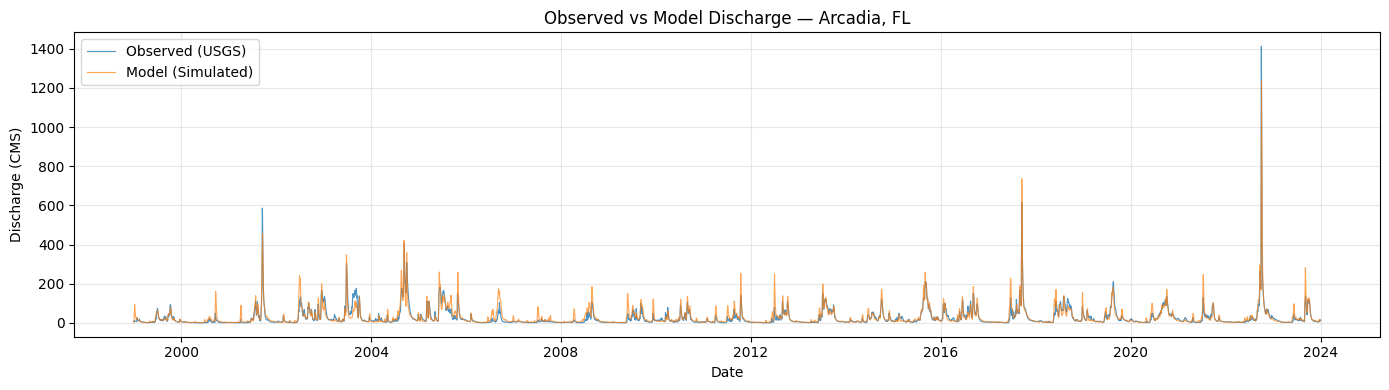

In [3]:
# ── 2a. Load observed discharge ───────────────────────────────────────────────
obs_raw = pd.read_csv(OBS_FILE, parse_dates=["Date"])
obs_raw = obs_raw[["Date", "Discharge_CMS"]].rename(columns={"Date": "time", "Discharge_CMS": "discharge"})
obs_raw = obs_raw.set_index("time").sort_index()
print(f"Observed : {obs_raw.shape[0]} daily rows  |  {obs_raw.index[0].date()} → {obs_raw.index[-1].date()}")

# ── 2b. Load model discharge ────────────────────────────────────────────────
mdl_raw = pd.read_csv(MODEL_FILE)
mdl_raw["time"] = pd.to_datetime(mdl_raw["SimDate"], format="mixed", dayfirst=False)
mdl_raw = mdl_raw[["time", "Flow"]].rename(columns={"Flow": "discharge"})
mdl_raw = mdl_raw.set_index("time").sort_index()

# Model has sub-daily entries (noon + midnight) → resample to daily mean
mdl_daily = mdl_raw.resample("D").mean()
mdl_daily = mdl_daily.dropna()
print(f"Model    : {mdl_daily.shape[0]} daily rows  |  {mdl_daily.index[0].date()} → {mdl_daily.index[-1].date()}")

# ── 2c. Inner-join on overlapping dates ──────────────────────────────────────
common_idx = obs_raw.index.intersection(mdl_daily.index)
obs = obs_raw.loc[common_idx].copy()
mdl = mdl_daily.loc[common_idx].copy()

print(f"\nOverlapping period: {common_idx[0].date()} → {common_idx[-1].date()}")
print(f"Common time steps : {len(common_idx)} days")

# Quick sanity plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(obs.index, obs["discharge"], label="Observed (USGS)", alpha=0.8, linewidth=0.8)
ax.plot(mdl.index, mdl["discharge"], label="Model (Simulated)", alpha=0.7, linewidth=0.8)
ax.set_xlabel("Date"); ax.set_ylabel("Discharge (CMS)")
ax.set_title("Observed vs Model Discharge — Arcadia, FL")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 3 — Standardise & Build Supervised Sequences

Z-score the model discharge, then create sliding-window sequences of length
`LOOKBACK` for training the LSTM.  The model data is used as the LSTM training
input (it acts as the "dynamical model"), and the observed data is the target
the EnKF will assimilate later.

In [4]:
N_STATE = 1  # single variable: discharge

# ── 3a. Standardise using the observed data statistics ───────────────────────
scaler = StandardScaler()
obs_std = scaler.fit_transform(obs[["discharge"]])          # fit on observations
mdl_std = scaler.transform(mdl[["discharge"]])              # transform model with same scaler

print(f"Obs std  — mean: {obs_std.mean():.4f}, std: {obs_std.std():.4f}")
print(f"Model std — mean: {mdl_std.mean():.4f}, std: {mdl_std.std():.4f}")

# ── 3b. Build sliding-window sequences from MODEL data ──────────────────────
def build_sequences(data, lookback):
    """Create (X, y) pairs: X[i] = data[i:i+lookback], y[i] = data[i+lookback]."""
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

X_all, y_all = build_sequences(mdl_std, LOOKBACK)
print(f"\nSequences: X={X_all.shape}, y={y_all.shape}")

# ── 3c. Train / val split (80/20 temporal) ───────────────────────────────────
split = int(len(X_all) * 0.8)
X_train, X_val = X_all[:split], X_all[split:]
y_train, y_val = y_all[:split], y_all[split:]
print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}")

Obs std  — mean: 0.0000, std: 1.0000
Model std — mean: 0.0652, std: 1.0398

Sequences: X=(9119, 12, 1), y=(9119, 1)
Train: 7295  |  Val: 1824


## Step 4 — Train LSTM Forecast Model

Architecture: `LSTM(64) → Dense(64, ReLU) → Dense(1, linear)`

The LSTM learns to predict next-day discharge from the previous 12 days of
model-simulated discharge.  It serves as the dynamical forecast operator
$\mathcal{M}$ inside the EnKF.

c:\Users\John\anaconda3\envs\week3_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,121 (82.50 KB)

 Trainable params: 21,121 (82.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1201 - val_loss: 0.2314
Epoch 2/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0152 - val_loss: 0.1106
Epoch 3/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084 - val_loss: 0.0751
Epoch 4/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - val_loss: 0.0534
Epoch 5/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049 - val_loss: 0.0450
Epoch 6/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042 - val_loss: 0.0388
Epoch 7/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0038 - val_loss: 0.0334
Epoch 8/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - val_loss: 0.0311
Epoch 9/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - val_loss: 0.0266
Epoch 10/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - val_loss: 0.0251
Epoch 11/200
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032 - val_loss: 0.0224
Epoch 12/200
228/228 ━━━━━━━━━━━━━━━━━━━━

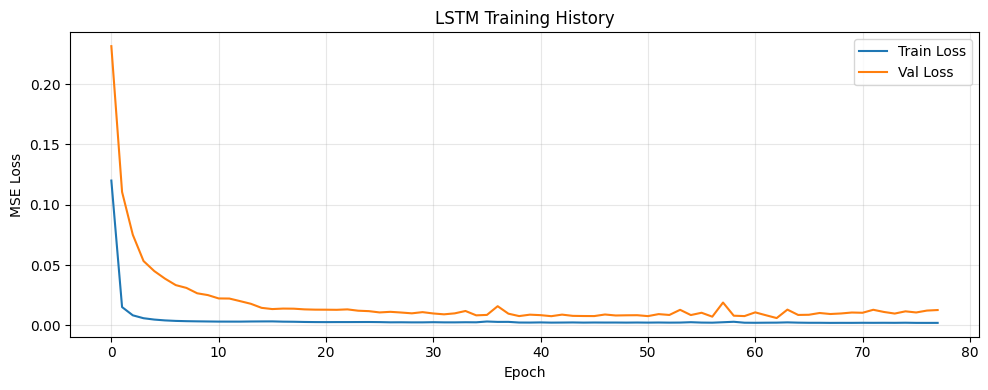

In [5]:
# ── 4a. Build LSTM ────────────────────────────────────────────────────────────
model = models.Sequential([
    layers.LSTM(LSTM_UNITS, input_shape=(LOOKBACK, N_STATE)),
    layers.Dense(DENSE_UNITS, activation="relu"),
    layers.Dense(N_STATE, activation="linear"),
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss="mse")
model.summary()

# ── 4b. Train ────────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=PATIENCE, restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

print(f"\nStopped at epoch {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

# ── 4c. Training history plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("LSTM Training History")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 5 — Estimate Uncertainty: Q (Process Noise) and R (Observation Error)

**Uncertainty method: Residual-based Type A evaluation (GUM)**

- **Q** (process noise covariance): estimated from the sample variance of the
  LSTM's training residuals $\epsilon = y_{\text{true}} - \hat{y}$.
  This quantifies the model's inherent forecast error.
- **R** (observation error variance): set to 20 % of the standardised observation
  variance, representing measurement and representativeness uncertainty.

In [6]:
# ── 5a. Process noise Q from training residuals ─────────────────────────────
y_train_pred = model.predict(X_train, verbose=0)
residuals = y_train - y_train_pred                 # (n_train, 1)

# For a single variable Q is a scalar (variance of residuals)
Q = float(np.var(residuals, ddof=1))               # Type A: sample variance
print(f"Process noise  Q = {Q:.6f}  (std = {np.sqrt(Q):.4f})")

# ── 5b. Observation error R ─────────────────────────────────────────────────
obs_var = float(np.var(obs_std, ddof=1))
R = OBS_ERR_FACTOR * obs_var                       # R = 0.2 × Var(obs_std)
print(f"Observation err R = {R:.6f}  (std = {np.sqrt(R):.4f})")
print(f"  (OBS_ERR_FACTOR = {OBS_ERR_FACTOR}, obs_var = {obs_var:.4f})")

Process noise  Q = 0.002118  (std = 0.0460)
Observation err R = 0.200022  (std = 0.4472)
  (OBS_ERR_FACTOR = 0.2, obs_var = 1.0001)


## Step 6 — Ensemble Kalman Filter (EnKF)

Run a 50-member perturbed-observation EnKF through the full time series:

1. **Forecast**: push each member through the LSTM + process noise $\sim \mathcal{N}(0, Q)$
2. **Kalman Gain**: $K = P_f / (P_f + R)$ (scalar case)
3. **Analysis**: $x_a^{(m)} = x_f^{(m)} + K \cdot (y^{(m)} - x_f^{(m)})$ with $y^{(m)} = y_{obs} + \epsilon_r$

In [7]:
T = len(obs_std)                     # total time steps
print(f"Running EnKF — {M_ENSEMBLE} members × {T} time steps …\n")

# Storage: (T, M) — each column is one ensemble member
ens_forecast = np.zeros((T, M_ENSEMBLE))
ens_analysis = np.zeros((T, M_ENSEMBLE))

# ── 6a. Initialise ensemble from the first observed value + small noise ──────
for m in range(M_ENSEMBLE):
    ens_analysis[0, m] = obs_std[0, 0] + np.random.normal(0, 0.01)

# History buffer per member: shape (M, LOOKBACK, 1)
# Seed from the standardised model data for the first LOOKBACK days
histories = np.zeros((M_ENSEMBLE, LOOKBACK, N_STATE))
for m in range(M_ENSEMBLE):
    histories[m] = mdl_std[:LOOKBACK]

# ── 6b. EnKF loop ───────────────────────────────────────────────────────────
for t in range(LOOKBACK, T):
    # ── Forecast step ────────────────────────────────────────────────────
    batch_in = histories.copy()                          # (M, LOOKBACK, 1)
    preds = model.predict(batch_in, verbose=0)           # (M, 1)
    proc_noise = np.random.normal(0, np.sqrt(Q), size=(M_ENSEMBLE, 1))
    x_f = preds + proc_noise                             # (M, 1)
    ens_forecast[t, :] = x_f[:, 0]

    # ── Ensemble statistics ──────────────────────────────────────────────
    x_f_mean = x_f.mean()
    P_f = np.var(x_f, ddof=1)                            # scalar prior variance

    # ── Kalman gain (scalar) ─────────────────────────────────────────────
    K = P_f / (P_f + R)

    # ── Analysis step with perturbed observations ────────────────────────
    y_obs = obs_std[t, 0]
    for m in range(M_ENSEMBLE):
        y_pert = y_obs + np.random.normal(0, np.sqrt(R))
        ens_analysis[t, m] = x_f[m, 0] + K * (y_pert - x_f[m, 0])

    # ── Update history buffers with analysed values ──────────────────────
    for m in range(M_ENSEMBLE):
        histories[m] = np.roll(histories[m], -1, axis=0)
        histories[m, -1, 0] = ens_analysis[t, m]

    if (t + 1) % 1000 == 0:
        print(f"  t = {t+1:,}/{T:,}  |  K = {K:.4f}  |  P_f = {P_f:.4f}")

# Fill the first LOOKBACK rows from observations (no filter applied)
for t in range(LOOKBACK):
    ens_analysis[t, :] = obs_std[t, 0]
    ens_forecast[t, :] = mdl_std[t, 0]

print(f"\n✅ EnKF complete — {T:,} time steps processed.")

Running EnKF — 50 members × 9131 time steps …

  t = 1,000/9,131  |  K = 0.8958  |  P_f = 1.7205
  t = 2,000/9,131  |  K = 0.5682  |  P_f = 0.2632
  t = 3,000/9,131  |  K = 0.6267  |  P_f = 0.3358
  t = 4,000/9,131  |  K = 0.4853  |  P_f = 0.1886
  t = 5,000/9,131  |  K = 0.7685  |  P_f = 0.6640
  t = 6,000/9,131  |  K = 0.3871  |  P_f = 0.1263
  t = 7,000/9,131  |  K = 0.4025  |  P_f = 0.1348
  t = 8,000/9,131  |  K = 0.6825  |  P_f = 0.4299
  t = 9,000/9,131  |  K = 0.6554  |  P_f = 0.3804

✅ EnKF complete — 9,131 time steps processed.


## Step 7 — Generate Open-Loop Baseline (No Data Assimilation)

Same LSTM + process noise, but **no analysis step** — observations are never
assimilated.  This shows how far the pure model drifts without correction.

In [8]:
# ── Open-loop: LSTM + process noise, no correction ───────────────────────────
openloop_std = np.zeros(T)
openloop_std[:LOOKBACK] = mdl_std[:LOOKBACK, 0]

ol_history = mdl_std[:LOOKBACK].copy().reshape(1, LOOKBACK, N_STATE)

for t in range(LOOKBACK, T):
    pred = model.predict(ol_history, verbose=0)[0, 0]
    noise = np.random.normal(0, np.sqrt(Q))
    openloop_std[t] = pred + noise

    ol_history = np.roll(ol_history, -1, axis=1)
    ol_history[0, -1, 0] = openloop_std[t]

    if (t + 1) % 1000 == 0:
        print(f"  Open-loop t = {t+1:,}/{T:,}")

print("✅ Open-loop generation complete.")

  Open-loop t = 1,000/9,131
  Open-loop t = 2,000/9,131
  Open-loop t = 3,000/9,131
  Open-loop t = 4,000/9,131
  Open-loop t = 5,000/9,131
  Open-loop t = 6,000/9,131
  Open-loop t = 7,000/9,131
  Open-loop t = 8,000/9,131
  Open-loop t = 9,000/9,131
✅ Open-loop generation complete.


## Step 8 — Inverse-Transform, Export CSVs & Visualise

Convert everything back from standardised space to **physical units (CMS)**,
then save:
- `obs_discharge.csv` — observed USGS discharge
- `model_openloop_discharge.csv` — LSTM open-loop (no DA)
- `reanalysis_discharge_mean.csv` — ensemble-mean reanalysis
- `reanalysis_discharge_ensemble.csv` — full 50-member ensemble

Saved → obs_discharge.csv  (9131 rows)
Saved → model_openloop_discharge.csv
Saved → reanalysis_discharge_mean.csv
Saved → reanalysis_discharge_ensemble.csv  (456,550 rows)
Saved → Discharge_Comparison.png


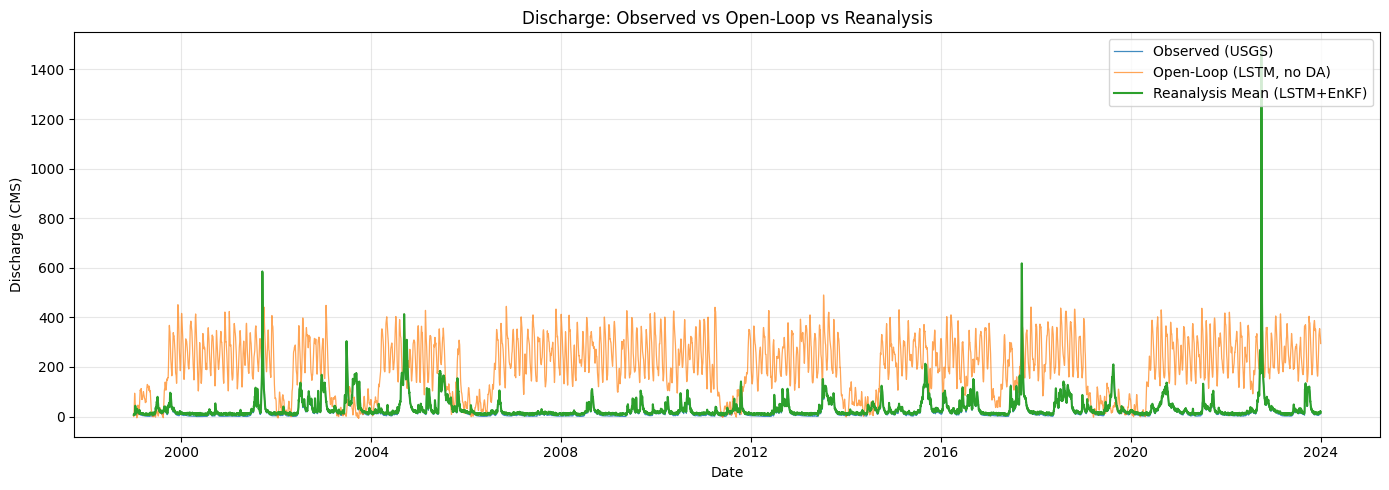

In [9]:
time_idx = obs.index   # common DatetimeIndex

# ── 8a. Inverse-transform to physical units (CMS) ───────────────────────────
def inv(arr):
    """Inverse-transform a 1-D standardised array back to CMS."""
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

rean_mean_std = ens_analysis.mean(axis=1)            # (T,)
rean_mean_cms = inv(rean_mean_std)
openloop_cms  = inv(openloop_std)
obs_cms       = obs["discharge"].values

# Full ensemble → physical units
ens_cms = np.zeros_like(ens_analysis)
for m in range(M_ENSEMBLE):
    ens_cms[:, m] = inv(ens_analysis[:, m])

# ── 8b. Save CSVs ───────────────────────────────────────────────────────────
# Observations
obs_out = pd.DataFrame({"time": time_idx, "discharge": obs_cms}).set_index("time")
obs_out.to_csv("obs_discharge.csv")
print(f"Saved → obs_discharge.csv  ({obs_out.shape[0]} rows)")

# Open-loop
ol_out = pd.DataFrame({"time": time_idx, "discharge": openloop_cms}).set_index("time")
ol_out.to_csv("model_openloop_discharge.csv")
print(f"Saved → model_openloop_discharge.csv")

# Reanalysis mean
rean_out = pd.DataFrame({"time": time_idx, "discharge": rean_mean_cms}).set_index("time")
rean_out.to_csv("reanalysis_discharge_mean.csv")
print(f"Saved → reanalysis_discharge_mean.csv")

# Full ensemble (long format)
ens_rows = []
for m in range(M_ENSEMBLE):
    for i, t in enumerate(time_idx):
        ens_rows.append({"time": t, "member": m, "discharge": ens_cms[i, m]})
ens_out = pd.DataFrame(ens_rows)
ens_out.to_csv("reanalysis_discharge_ensemble.csv", index=False)
print(f"Saved → reanalysis_discharge_ensemble.csv  ({len(ens_rows):,} rows)")

# ── 8c. Time-series comparison plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_idx, obs_cms, label="Observed (USGS)", linewidth=0.9, alpha=0.85)
ax.plot(time_idx, openloop_cms, label="Open-Loop (LSTM, no DA)", linewidth=0.9, alpha=0.7)
ax.plot(time_idx, rean_mean_cms, label="Reanalysis Mean (LSTM+EnKF)", linewidth=1.5)
ax.set_xlabel("Date"); ax.set_ylabel("Discharge (CMS)")
ax.set_title("Discharge: Observed vs Open-Loop vs Reanalysis")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Discharge_Comparison.png", dpi=300, bbox_inches="tight")
print("Saved → Discharge_Comparison.png")
plt.show()

## Step 9 — 95 % Confidence Interval Area & Integral

Plot the upper/lower 95 % CI bounds from the ensemble, shade the region
between them, overlay the reanalysis mean, and compute the integral of the
CI width using the trapezoidal rule.

95 % CI Area Integral:
  ∫ (Upper − Lower) dt  =  592,082.05  CMS·days
  Mean CI width         =  64.8462  CMS
  Max  CI width         =  113.5001  CMS
  Min  CI width         =  0.0000  CMS

Saved → CI_Area_Discharge.png

Saved → CI_Area_Discharge.png


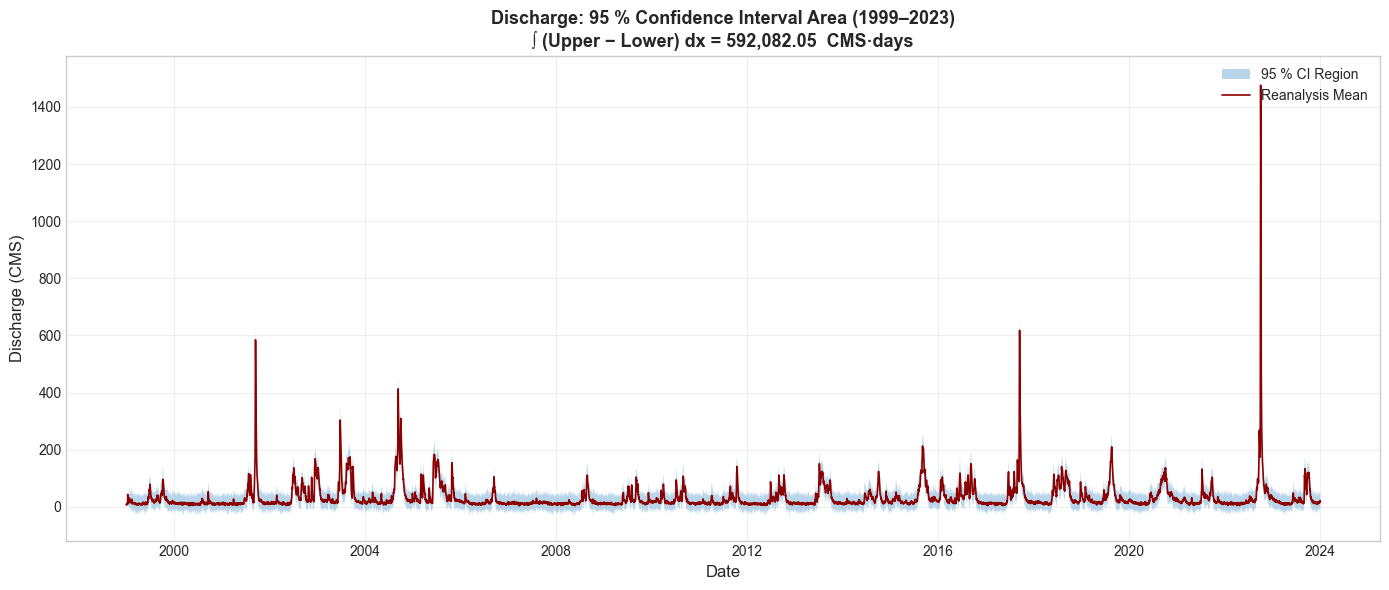


✅ Pipeline complete — all outputs saved.


In [13]:
# ── 9a. Compute 95 % CI in physical units ────────────────────────────────────
ci_lower = np.percentile(ens_cms, 2.5, axis=1)     # 2.5th percentile
ci_upper = np.percentile(ens_cms, 97.5, axis=1)    # 97.5th percentile

# ── 9b. Integral of CI width (trapezoidal rule) ─────────────────────────────
ci_width = ci_upper - ci_lower                      # (T,)
t_days = np.arange(T, dtype=float)                  # 0, 1, 2, … days
ci_integral = integrate.trapezoid(ci_width, x=t_days)

print(f"95 % CI Area Integral:")
print(f"  ∫ (Upper − Lower) dt  =  {ci_integral:,.2f}  CMS·days")
print(f"  Mean CI width         =  {ci_width.mean():,.4f}  CMS")
print(f"  Max  CI width         =  {ci_width.max():,.4f}  CMS")
print(f"  Min  CI width         =  {ci_width.min():,.4f}  CMS")

# ── 9c. CI area plot ─────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# Shaded region
ax.fill_between(
    time_idx, ci_lower, ci_upper,
    color="#7FB3D8", alpha=0.55, edgecolor="none", label="95 % CI Region",
)

# Reanalysis mean
ax.plot(time_idx, rean_mean_cms, color="#8B0000", linewidth=1.2, label="Reanalysis Mean")

start_yr = time_idx.min().year
end_yr   = time_idx.max().year
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Discharge (CMS)", fontsize=12)
ax.set_title(
    f"Discharge: 95 % Confidence Interval Area ({start_yr}–{end_yr})\n"
    f"∫ (Upper − Lower) dx = {ci_integral:,.2f}  CMS·days",
    fontsize=13, fontweight="bold",
)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("CI_Area_Discharge.png", dpi=300, bbox_inches="tight")
print("\nSaved → CI_Area_Discharge.png")
plt.show()

print("\n✅ Pipeline complete — all outputs saved.")

## Step 10 — Model Simulation vs Observations

Overlay the hydrological model's simulated daily discharge (solid line) with the
USGS-observed discharge (scatter dots) over the common period.

Saved → Model_vs_Observed_Discharge.png


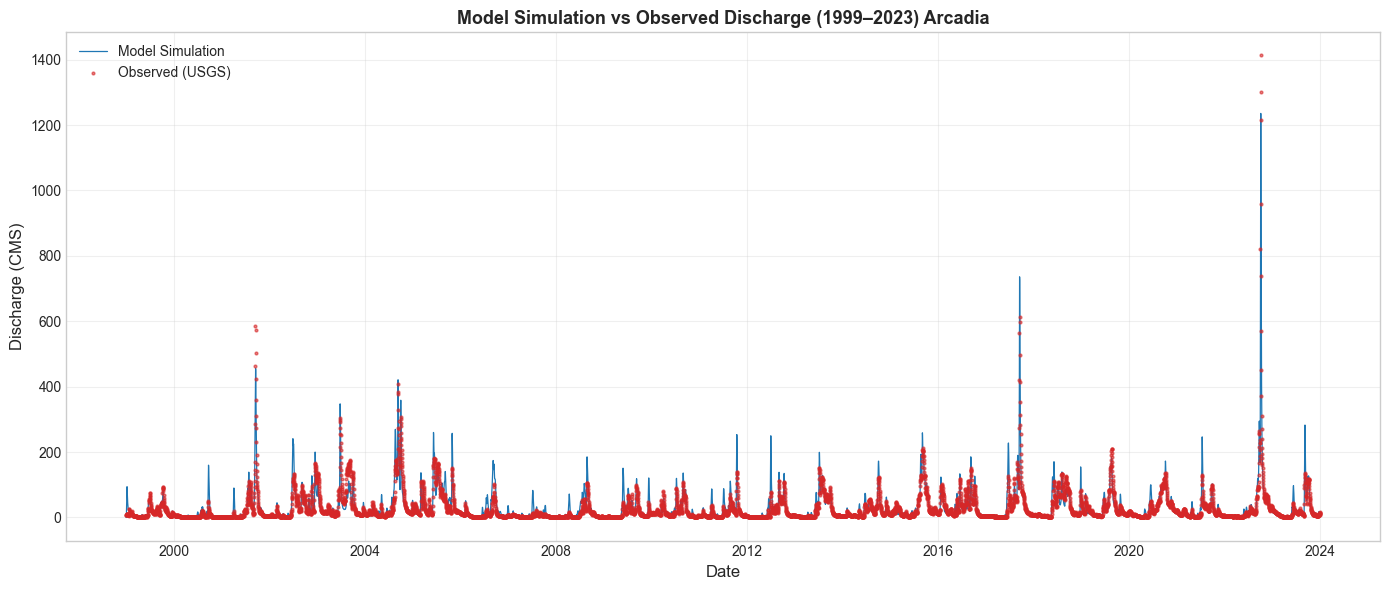

In [16]:
# ── 10. Model Simulation (line) vs Observations (dots) ───────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# Model simulation — solid line
ax.plot(
    time_idx, mdl.loc[time_idx, "discharge"].values,
    color="#1f77b4", linewidth=0.9, label="Model Simulation",
)

# Observations — scatter dots
ax.scatter(
    time_idx, obs_cms,
    s=4, color="#d62728", alpha=0.6, zorder=3, label="Observed (USGS)",
)

start_yr = time_idx.min().year
end_yr   = time_idx.max().year
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Discharge (CMS)", fontsize=12)
ax.set_title(
    f"Model Simulation vs Observed Discharge ({start_yr}–{end_yr}) Arcadia",
    fontsize=13, fontweight="bold",
)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Model_vs_Observed_Discharge.png", dpi=300, bbox_inches="tight")
print("Saved → Model_vs_Observed_Discharge.png")
plt.show()